# Schema-Aware Food Representation Pretraining

This Colab notebook trains a stronger food representation pretraining model than the first structured transformer run.

It keeps the existing FooDB food-level preprocessing, log-transformed nutrient and compound targets, and observed-value masks. The pretraining model is a schema-aware denoising transformer that learns from text fields, group metadata, nutrient tokens, and compound tokens while reconstructing masked numeric profiles and masked category fields.

## Setup

Run this first in a fresh Colab runtime. Dependencies are intentionally limited to common Colab-friendly packages already used in this project.

In [1]:
!pip install -q pandas numpy scikit-learn torch sentence-transformers tqdm matplotlib

In [2]:
from pathlib import Path

import torch

print('CUDA available:', torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

CUDA available: True
NVIDIA L4


## Mount Google Drive

Expected raw FooDB folder after mounting:

- `/content/drive/MyDrive/food_model/data/raw/foodb_2020_04_07_csv`

The notebook also checks this alternate folder:

- `/content/drive/MyDrive/FoodNutrition/foodb_2020_04_07_csv`

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATA_DIR = Path('/content/drive/MyDrive/food_model/data')
RAW_DIR = DATA_DIR / 'raw'
RAW_FOODB_DIR = RAW_DIR / 'foodb_2020_04_07_csv'
ALTERNATE_RAW_FOODB_DIR = Path('/content/drive/MyDrive/FoodNutrition/foodb_2020_04_07_csv')
OUTPUT_ROOT = Path('/content/drive/MyDrive/food_model/outputs')

for directory in [DATA_DIR, RAW_DIR, OUTPUT_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('RAW_FOODB_DIR:', RAW_FOODB_DIR, 'exists=', RAW_FOODB_DIR.exists())
print('ALTERNATE_RAW_FOODB_DIR:', ALTERNATE_RAW_FOODB_DIR, 'exists=', ALTERNATE_RAW_FOODB_DIR.exists())
print('OUTPUT_ROOT:', OUTPUT_ROOT)

DATA_DIR: /content/drive/MyDrive/food_model/data
RAW_FOODB_DIR: /content/drive/MyDrive/food_model/data/raw/foodb_2020_04_07_csv exists= True
ALTERNATE_RAW_FOODB_DIR: /content/drive/MyDrive/FoodNutrition/foodb_2020_04_07_csv exists= False
OUTPUT_ROOT: /content/drive/MyDrive/food_model/outputs


## Optional Raw Data Extraction

Skip this cell if `RAW_FOODB_DIR` or `ALTERNATE_RAW_FOODB_DIR` already exists.

In [5]:
# Example only. Edit this path if your archive is elsewhere.
# ARCHIVE_PATH = Path('/content/drive/MyDrive/FoodNutrition/foodb_2020_4_7_csv.tar.gz')
# !file "{ARCHIVE_PATH}"
# !tar -xzf "{ARCHIVE_PATH}" -C "{RAW_DIR}"
#
# If gzip extraction fails with 'not in gzip format', try plain tar:
# !tar -xf "{ARCHIVE_PATH}" -C "{RAW_DIR}"

## Make Project Code Available

Set `PROJECT_ROOT` to the repository folder in Colab. The notebook imports the existing preprocessing utilities from `src/models/structured_transformer_pretraining.py` and defines the new pretraining model inline below.

In [6]:
import sys

PROJECT_ROOT_CANDIDATES = [
    Path('/content/FoodNutrition'),
    Path('/content/drive/MyDrive/FoodNutrition'),
]

PROJECT_ROOT = None
for candidate in PROJECT_ROOT_CANDIDATES:
    if (candidate / 'src/models/structured_transformer_pretraining.py').exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    print('Could not find src/models/structured_transformer_pretraining.py in:')
    for candidate in PROJECT_ROOT_CANDIDATES:
        print(' -', candidate)
    raise FileNotFoundError('Clone/copy the repository to one of the candidate folders, or edit PROJECT_ROOT_CANDIDATES.')

sys.path.insert(0, str(PROJECT_ROOT))
print('Using project root:', PROJECT_ROOT)

Using project root: /content/drive/MyDrive/FoodNutrition


## Pretraining Model Outline

The previous report shows that the structured transformer objective is executable and reduces validation pretraining loss, but it does not yet prove held-out nutrient or compound prediction quality. This notebook trains a more demanding pretraining model and evaluates it against simple baselines.

Model outline:

1. **Inputs**: `[CLS]`, three frozen MiniLM text-field tokens, group token, subgroup token, one token per nutrient, and one token per compound.
2. **Schema-aware numeric tokens**: each nutrient or compound token combines feature identity, transformed numeric value, observed/masked/missing state, token type, and position.
3. **Denoising schedule**: randomly masks individual observed nutrient/compound values and sometimes masks the full observed numeric profile. Full-profile masking forces the model to predict nutrients and compounds from text plus metadata instead of copying visible values.
4. **Metadata corruption**: masks group and subgroup together so category prediction cannot be solved by trivial leakage between the two fields.
5. **Text-field dropout**: occasionally drops a text field embedding so the model does not depend on one metadata phrase being present every time.
6. **Transformer encoder**: bidirectional schema transformer over the fixed food-token sequence.
7. **Prediction heads**: separate feature-specific nutrient and compound numeric heads, plus group and subgroup classifiers.
8. **Evaluation**: profile reconstruction on the held-out test foods, compared with global mean, food-group mean, and text-embedding kNN baselines. Metrics are reported on transformed values and original-scale values; missing targets are never evaluated.

## Configure Training

The defaults are sized for a Colab GPU. If memory is tight, lower `batch_size` first, then `n_layers`.

In [7]:
from src.models.structured_transformer_pretraining import TransformerPretrainingConfig

config = TransformerPretrainingConfig(
    data_dir=str(DATA_DIR),
    output_dir=str(OUTPUT_ROOT / 'schema_denoising_transformer'),
    raw_foodb_dir=str(RAW_FOODB_DIR),
    alternate_raw_foodb_dir=str(ALTERNATE_RAW_FOODB_DIR),
    force_rebuild_processed_data=False,
    batch_size=12,
    epochs=40,
    patience=7,
    learning_rate=8e-5,
    weight_decay=1e-4,
    d_model=256,
    n_heads=8,
    n_layers=6,
    dim_feedforward=768,
    dropout=0.15,
    numeric_mask_prob=0.20,
    group_subgroup_mask_prob=0.35,
    lambda_nutrient=1.0,
    lambda_compound=1.0,
    lambda_group=0.1,
    lambda_subgroup=0.1,
)

PROFILE_MASK_PROB = 0.20
TEXT_FIELD_DROPOUT_PROB = 0.10
KNN_K = 10

config

TransformerPretrainingConfig(data_dir='/content/drive/MyDrive/food_model/data', output_dir='/content/drive/MyDrive/food_model/outputs/schema_denoising_transformer', raw_foodb_dir='/content/drive/MyDrive/food_model/data/raw/foodb_2020_04_07_csv', alternate_raw_foodb_dir='/content/drive/MyDrive/FoodNutrition/foodb_2020_04_07_csv', processed_filename='food_model_table_transformer.csv', force_rebuild_processed_data=False, min_compound_observations=20, sentence_model_name='sentence-transformers/all-MiniLM-L6-v2', text_embedding_batch_size=64, seed=42, batch_size=12, epochs=40, patience=7, learning_rate=8e-05, weight_decay=0.0001, d_model=256, n_heads=8, n_layers=6, dim_feedforward=768, dropout=0.15, numeric_mask_prob=0.2, group_subgroup_mask_prob=0.35, lambda_nutrient=1.0, lambda_compound=1.0, lambda_group=0.1, lambda_subgroup=0.1)

## Load Food-Level Data

This reuses the existing preprocessing pipeline: missing nutrient and compound values stay missing, observed numeric values are log-transformed, and the split is food-level.

In [8]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset

from src.models.structured_transformer_pretraining import (
    BASE_METADATA_COLUMNS,
    TEXT_FIELD_COLUMNS,
    build_datasets,
    encode_text_fields,
    load_or_build_processed_table,
    prepare_target_bundle,
    save_label_mapping,
    set_seed,
)

set_seed(config.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

output_dir = Path(config.output_dir)
output_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = output_dir / 'schema_denoising_food_transformer.pt'
config_path = output_dir / 'schema_denoising_food_transformer_config.json'
metrics_path = output_dir / 'schema_denoising_food_transformer_history.csv'
text_cache_path = Path(config.data_dir) / 'processed' / 'food_text_field_embeddings_transformer.npy'

df = load_or_build_processed_table(config).reset_index(drop=True)
for column in BASE_METADATA_COLUMNS:
    if column not in df.columns:
        raise ValueError(f'Processed table is missing required metadata column: {column}')

nutrient_columns = sorted([column for column in df.columns if column.startswith('nutrient__')])
compound_columns = sorted([column for column in df.columns if column.startswith('compound__')])
if not nutrient_columns or not compound_columns:
    raise ValueError('Expected both nutrient__ and compound__ columns for pretraining.')

print('Data shape:', df.shape)
print('Nutrients:', len(nutrient_columns))
print('Compounds:', len(compound_columns))

nutrient_bundle = prepare_target_bundle(df, nutrient_columns, 'nutrient')
compound_bundle = prepare_target_bundle(df, compound_columns, 'compound')
assert nutrient_bundle is not None
assert compound_bundle is not None

text_field_embeddings = encode_text_fields(df, config, device, text_cache_path)
split_indices, _, group_encoder, subgroup_encoder = build_datasets(
    df=df,
    text_field_embeddings=text_field_embeddings,
    nutrient_bundle=nutrient_bundle,
    compound_bundle=compound_bundle,
    config=config,
)

group_labels = group_encoder.transform(df['food_group'].fillna('unknown').astype(str))
subgroup_labels = subgroup_encoder.transform(df['food_subgroup'].fillna('unknown').astype(str))

print('Text field embedding shape:', text_field_embeddings.shape)
print('Group classes:', len(group_encoder.classes_))
print('Subgroup classes:', len(subgroup_encoder.classes_))

Using device: cuda
NVIDIA L4
Loaded processed dataset from: /content/drive/MyDrive/food_model/data/processed/food_model_table_transformer.csv
Data shape: (992, 338)
Nutrients: 39
Compounds: 293
Prepared nutrient bundle with shape raw=(992, 39), mask=(992, 39), transformed=(992, 39)
Prepared compound bundle with shape raw=(992, 293), mask=(992, 293), transformed=(992, 293)
Loaded text-field embedding cache from: /content/drive/MyDrive/food_model/data/processed/food_text_field_embeddings_transformer.npy
train: rows=694, unique_foods=694
val: rows=149, unique_foods=149
test: rows=149, unique_foods=149
Text field embedding shape: (992, 3, 384)
Group classes: 25
Subgroup classes: 120


## Define The Schema-Aware Denoising Transformer

This cell defines the dataset corruption policy, the transformer, and the masked losses. It is self-contained so the notebook can be run after cloning/copying the repository to Colab.

In [9]:
import json
from dataclasses import asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from tqdm.auto import tqdm


class SchemaDenoisingFoodDataset(Dataset):
    VALUE_STATE_OBSERVED = 0
    VALUE_STATE_MASKED = 1
    VALUE_STATE_MISSING = 2
    TEXT_STATE_OBSERVED = 0
    TEXT_STATE_DROPPED = 1

    def __init__(
        self,
        indices,
        text_field_embeddings,
        nutrient_targets,
        nutrient_observed_mask,
        compound_targets,
        compound_observed_mask,
        group_labels,
        subgroup_labels,
        numeric_mask_prob,
        profile_mask_prob,
        metadata_mask_prob,
        text_field_dropout_prob,
        enable_random_corruption=True,
        force_profile_mask=False,
        force_metadata_mask=False,
    ):
        self.indices = np.asarray(indices, dtype=np.int64)
        self.text_field_embeddings = torch.tensor(text_field_embeddings[self.indices], dtype=torch.float32)
        self.nutrient_targets = torch.tensor(nutrient_targets[self.indices], dtype=torch.float32)
        self.nutrient_observed_mask = torch.tensor(nutrient_observed_mask[self.indices], dtype=torch.float32)
        self.compound_targets = torch.tensor(compound_targets[self.indices], dtype=torch.float32)
        self.compound_observed_mask = torch.tensor(compound_observed_mask[self.indices], dtype=torch.float32)
        self.group_labels = torch.tensor(np.asarray(group_labels)[self.indices], dtype=torch.long)
        self.subgroup_labels = torch.tensor(np.asarray(subgroup_labels)[self.indices], dtype=torch.long)
        self.numeric_mask_prob = float(numeric_mask_prob)
        self.profile_mask_prob = float(profile_mask_prob)
        self.metadata_mask_prob = float(metadata_mask_prob)
        self.text_field_dropout_prob = float(text_field_dropout_prob)
        self.enable_random_corruption = bool(enable_random_corruption)
        self.force_profile_mask = bool(force_profile_mask)
        self.force_metadata_mask = bool(force_metadata_mask)

        num_rows = self.text_field_embeddings.shape[0]
        assert self.nutrient_targets.shape[0] == num_rows
        assert self.nutrient_observed_mask.shape == self.nutrient_targets.shape
        assert self.compound_targets.shape[0] == num_rows
        assert self.compound_observed_mask.shape == self.compound_targets.shape
        assert self.group_labels.shape[0] == num_rows
        assert self.subgroup_labels.shape[0] == num_rows

    def __len__(self):
        return self.text_field_embeddings.shape[0]

    def _mask_numeric_values(self, target, observed_mask):
        observed = observed_mask > 0
        if self.force_profile_mask:
            prediction_mask = observed.float()
        elif self.enable_random_corruption:
            if torch.rand(()) < self.profile_mask_prob:
                prediction_mask = observed.float()
            else:
                random_values = torch.rand_like(target)
                prediction_mask = ((random_values < self.numeric_mask_prob) & observed).float()
        else:
            prediction_mask = torch.zeros_like(target)

        visible_observed_mask = (observed & (prediction_mask == 0)).float()
        input_values = target * visible_observed_mask
        value_state = torch.full_like(target, self.VALUE_STATE_MISSING, dtype=torch.long)
        value_state[visible_observed_mask.bool()] = self.VALUE_STATE_OBSERVED
        value_state[prediction_mask.bool()] = self.VALUE_STATE_MASKED
        return input_values, value_state, prediction_mask

    def _corrupt_text_fields(self, text_fields):
        text_fields = text_fields.clone()
        text_state = torch.full(
            (text_fields.shape[0],),
            self.TEXT_STATE_OBSERVED,
            dtype=torch.long,
        )
        if self.enable_random_corruption and self.text_field_dropout_prob > 0:
            drop_mask = torch.rand(text_fields.shape[0]) < self.text_field_dropout_prob
            if bool(drop_mask.all()):
                keep_index = torch.randint(0, text_fields.shape[0], (1,)).item()
                drop_mask[keep_index] = False
            text_fields[drop_mask] = 0.0
            text_state[drop_mask] = self.TEXT_STATE_DROPPED
        return text_fields, text_state

    def __getitem__(self, index):
        nutrient_input, nutrient_state, nutrient_prediction_mask = self._mask_numeric_values(
            self.nutrient_targets[index],
            self.nutrient_observed_mask[index],
        )
        compound_input, compound_state, compound_prediction_mask = self._mask_numeric_values(
            self.compound_targets[index],
            self.compound_observed_mask[index],
        )
        text_fields, text_state = self._corrupt_text_fields(self.text_field_embeddings[index])

        metadata_masked = self.force_metadata_mask
        if self.enable_random_corruption:
            metadata_masked = metadata_masked or bool(torch.rand(()) < self.metadata_mask_prob)
        metadata_prediction_mask = torch.tensor(float(metadata_masked), dtype=torch.float32)

        return {
            'text_field_embeddings': text_fields,
            'text_state': text_state,
            'nutrient_input': nutrient_input,
            'nutrient_state': nutrient_state,
            'nutrient_target': self.nutrient_targets[index],
            'nutrient_observed_mask': self.nutrient_observed_mask[index],
            'nutrient_prediction_mask': nutrient_prediction_mask,
            'compound_input': compound_input,
            'compound_state': compound_state,
            'compound_target': self.compound_targets[index],
            'compound_observed_mask': self.compound_observed_mask[index],
            'compound_prediction_mask': compound_prediction_mask,
            'group_label': self.group_labels[index],
            'subgroup_label': self.subgroup_labels[index],
            'group_prediction_mask': metadata_prediction_mask,
            'subgroup_prediction_mask': metadata_prediction_mask,
        }


class FeatureSpecificNumericHead(nn.Module):
    def __init__(self, d_model, num_features, dropout):
        super().__init__()
        hidden_dim = max(64, d_model // 2)
        self.shared = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
        self.feature_scale = nn.Parameter(torch.ones(num_features))
        self.feature_bias = nn.Parameter(torch.zeros(num_features))

    def forward(self, hidden_states):
        base = self.shared(hidden_states).squeeze(-1)
        return base * self.feature_scale.unsqueeze(0) + self.feature_bias.unsqueeze(0)


class SchemaAwareDenoisingTransformer(nn.Module):
    def __init__(
        self,
        text_dim,
        num_text_fields,
        num_nutrients,
        num_compounds,
        num_groups,
        num_subgroups,
        config,
    ):
        super().__init__()
        self.num_text_fields = num_text_fields
        self.num_nutrients = num_nutrients
        self.num_compounds = num_compounds
        self.num_groups = num_groups
        self.num_subgroups = num_subgroups
        self.group_mask_id = num_groups
        self.subgroup_mask_id = num_subgroups

        d_model = config.d_model
        self.sequence_length = 1 + num_text_fields + 2 + num_nutrients + num_compounds

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.text_projection = nn.Sequential(
            nn.LayerNorm(text_dim),
            nn.Linear(text_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )
        self.text_field_embedding = nn.Embedding(num_text_fields, d_model)
        self.text_state_embedding = nn.Embedding(2, d_model)
        self.token_type_embedding = nn.Embedding(8, d_model)
        self.position_embedding = nn.Embedding(self.sequence_length, d_model)
        self.group_embedding = nn.Embedding(num_groups + 1, d_model)
        self.subgroup_embedding = nn.Embedding(num_subgroups + 1, d_model)
        self.nutrient_feature_embedding = nn.Embedding(num_nutrients, d_model)
        self.compound_feature_embedding = nn.Embedding(num_compounds, d_model)
        self.value_state_embedding = nn.Embedding(3, d_model)
        self.nutrient_value_projection = nn.Sequential(
            nn.Linear(1, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
        )
        self.compound_value_projection = nn.Sequential(
            nn.Linear(1, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
        )
        self.input_norm = nn.LayerNorm(d_model)
        self.input_dropout = nn.Dropout(config.dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=config.n_heads,
            dim_feedforward=config.dim_feedforward,
            dropout=config.dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=config.n_layers)
        self.final_norm = nn.LayerNorm(d_model)
        self.nutrient_head = FeatureSpecificNumericHead(d_model, num_nutrients, config.dropout)
        self.compound_head = FeatureSpecificNumericHead(d_model, num_compounds, config.dropout)
        self.group_head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, num_groups))
        self.subgroup_head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, num_subgroups))

        nn.init.normal_(self.cls_token, std=0.02)

    def _type_ids(self, batch_size, device):
        ids = [0]
        ids.extend([1, 2, 3][: self.num_text_fields])
        ids.extend([4, 5])
        ids.extend([6] * self.num_nutrients)
        ids.extend([7] * self.num_compounds)
        return torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0).expand(batch_size, -1)

    def forward(self, batch):
        text_fields = batch['text_field_embeddings']
        batch_size = text_fields.shape[0]
        device = text_fields.device

        cls_token = self.cls_token.expand(batch_size, -1, -1)
        text_ids = torch.arange(self.num_text_fields, device=device).unsqueeze(0).expand(batch_size, -1)
        text_tokens = (
            self.text_projection(text_fields)
            + self.text_field_embedding(text_ids)
            + self.text_state_embedding(batch['text_state'])
        )

        group_input_ids = batch['group_label'].clone()
        subgroup_input_ids = batch['subgroup_label'].clone()
        group_mask = batch['group_prediction_mask'].bool()
        subgroup_mask = batch['subgroup_prediction_mask'].bool()
        group_input_ids[group_mask] = self.group_mask_id
        subgroup_input_ids[subgroup_mask] = self.subgroup_mask_id
        group_token = self.group_embedding(group_input_ids).unsqueeze(1)
        subgroup_token = self.subgroup_embedding(subgroup_input_ids).unsqueeze(1)

        nutrient_ids = torch.arange(self.num_nutrients, device=device).unsqueeze(0).expand(batch_size, -1)
        compound_ids = torch.arange(self.num_compounds, device=device).unsqueeze(0).expand(batch_size, -1)
        nutrient_tokens = (
            self.nutrient_feature_embedding(nutrient_ids)
            + self.nutrient_value_projection(batch['nutrient_input'].unsqueeze(-1))
            + self.value_state_embedding(batch['nutrient_state'])
        )
        compound_tokens = (
            self.compound_feature_embedding(compound_ids)
            + self.compound_value_projection(batch['compound_input'].unsqueeze(-1))
            + self.value_state_embedding(batch['compound_state'])
        )

        tokens = torch.cat(
            [cls_token, text_tokens, group_token, subgroup_token, nutrient_tokens, compound_tokens],
            dim=1,
        )
        if tokens.shape[1] != self.sequence_length:
            raise ValueError(f'Expected sequence length {self.sequence_length}, got {tokens.shape[1]}.')

        position_ids = torch.arange(self.sequence_length, device=device).unsqueeze(0).expand(batch_size, -1)
        type_ids = self._type_ids(batch_size, device)
        tokens = tokens + self.position_embedding(position_ids) + self.token_type_embedding(type_ids)
        tokens = self.input_dropout(self.input_norm(tokens))
        encoded = self.final_norm(self.encoder(tokens))

        group_position = 1 + self.num_text_fields
        subgroup_position = group_position + 1
        nutrient_start = subgroup_position + 1
        compound_start = nutrient_start + self.num_nutrients
        nutrient_encoded = encoded[:, nutrient_start:compound_start]
        compound_encoded = encoded[:, compound_start : compound_start + self.num_compounds]

        return {
            'food_embedding': encoded[:, 0],
            'group_logits': self.group_head(encoded[:, group_position]),
            'subgroup_logits': self.subgroup_head(encoded[:, subgroup_position]),
            'nutrient_pred': self.nutrient_head(nutrient_encoded),
            'compound_pred': self.compound_head(compound_encoded),
        }


def masked_mse(pred, target, mask, eps=1e-8):
    assert pred.shape == target.shape
    assert mask.shape == target.shape
    loss = ((pred - target) ** 2) * mask
    return loss.sum() / (mask.sum() + eps)


def masked_cross_entropy(logits, target, mask):
    active_mask = mask.bool()
    if not bool(active_mask.any()):
        return logits.sum() * 0.0
    return F.cross_entropy(logits[active_mask], target[active_mask])


def compute_schema_losses(outputs, batch, config):
    nutrient_loss = masked_mse(
        outputs['nutrient_pred'],
        batch['nutrient_target'],
        batch['nutrient_prediction_mask'],
    )
    compound_loss = masked_mse(
        outputs['compound_pred'],
        batch['compound_target'],
        batch['compound_prediction_mask'],
    )
    group_loss = masked_cross_entropy(
        outputs['group_logits'],
        batch['group_label'],
        batch['group_prediction_mask'],
    )
    subgroup_loss = masked_cross_entropy(
        outputs['subgroup_logits'],
        batch['subgroup_label'],
        batch['subgroup_prediction_mask'],
    )
    total_loss = (
        config.lambda_nutrient * nutrient_loss
        + config.lambda_compound * compound_loss
        + config.lambda_group * group_loss
        + config.lambda_subgroup * subgroup_loss
    )
    return {
        'total': total_loss,
        'nutrient': nutrient_loss,
        'compound': compound_loss,
        'group': group_loss,
        'subgroup': subgroup_loss,
    }


def move_batch_to_device(batch, device):
    return {key: value.to(device) for key, value in batch.items()}


def run_schema_epoch(model, loader, config, device, optimizer=None, scheduler=None):
    is_training = optimizer is not None
    model.train(is_training)
    metric_sums = {'total': 0.0, 'nutrient': 0.0, 'compound': 0.0, 'group': 0.0, 'subgroup': 0.0}
    row_count = 0

    for batch in tqdm(loader, leave=False):
        batch = move_batch_to_device(batch, device)
        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            outputs = model(batch)
            losses = compute_schema_losses(outputs, batch, config)
            if is_training:
                losses['total'].backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        batch_size = int(batch['text_field_embeddings'].shape[0])
        row_count += batch_size
        for key in metric_sums:
            metric_sums[key] += float(losses[key].detach().cpu()) * batch_size

    if is_training and scheduler is not None:
        scheduler.step()

    return {key: value / max(row_count, 1) for key, value in metric_sums.items()}


def make_schema_dataset(
    split_name,
    enable_random_corruption=True,
    force_profile_mask=False,
    force_metadata_mask=False,
):
    return SchemaDenoisingFoodDataset(
        indices=split_indices[split_name],
        text_field_embeddings=text_field_embeddings,
        nutrient_targets=nutrient_bundle['transformed'],
        nutrient_observed_mask=nutrient_bundle['mask'],
        compound_targets=compound_bundle['transformed'],
        compound_observed_mask=compound_bundle['mask'],
        group_labels=group_labels,
        subgroup_labels=subgroup_labels,
        numeric_mask_prob=config.numeric_mask_prob,
        profile_mask_prob=PROFILE_MASK_PROB,
        metadata_mask_prob=config.group_subgroup_mask_prob,
        text_field_dropout_prob=TEXT_FIELD_DROPOUT_PROB,
        enable_random_corruption=enable_random_corruption,
        force_profile_mask=force_profile_mask,
        force_metadata_mask=force_metadata_mask,
    )

## Train

The validation loss uses the same corruption objective as training. The best checkpoint is saved whenever validation total loss improves.

In [10]:
train_dataset = make_schema_dataset('train', enable_random_corruption=True)
val_dataset = make_schema_dataset('val', enable_random_corruption=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)

model = SchemaAwareDenoisingTransformer(
    text_dim=text_field_embeddings.shape[-1],
    num_text_fields=text_field_embeddings.shape[1],
    num_nutrients=len(nutrient_columns),
    num_compounds=len(compound_columns),
    num_groups=len(group_encoder.classes_),
    num_subgroups=len(subgroup_encoder.classes_),
    config=config,
).to(device)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print('Transformer sequence length:', model.sequence_length)
print(f'Model parameters: {parameter_count / 1_000_000:.2f}M')

optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs)
best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0
history = []

for epoch in range(1, config.epochs + 1):
    train_metrics = run_schema_epoch(model, train_loader, config, device, optimizer=optimizer, scheduler=scheduler)
    val_metrics = run_schema_epoch(model, val_loader, config, device, optimizer=None)
    current_lr = optimizer.param_groups[0]['lr']
    history_row = {
        'epoch': epoch,
        'learning_rate': current_lr,
        **{f'train_{key}': value for key, value in train_metrics.items()},
        **{f'val_{key}': value for key, value in val_metrics.items()},
    }
    history.append(history_row)
    print(
        f"Epoch {epoch:02d} | lr={current_lr:.2e} | "
        f"train total={train_metrics['total']:.4f} nutrient={train_metrics['nutrient']:.4f} "
        f"compound={train_metrics['compound']:.4f} group={train_metrics['group']:.4f} "
        f"subgroup={train_metrics['subgroup']:.4f} | "
        f"val total={val_metrics['total']:.4f} nutrient={val_metrics['nutrient']:.4f} "
        f"compound={val_metrics['compound']:.4f} group={val_metrics['group']:.4f} "
        f"subgroup={val_metrics['subgroup']:.4f}"
    )

    if val_metrics['total'] < best_val_loss:
        best_val_loss = val_metrics['total']
        best_epoch = epoch
        patience_counter = 0
        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'config': asdict(config),
                'profile_mask_prob': PROFILE_MASK_PROB,
                'text_field_dropout_prob': TEXT_FIELD_DROPOUT_PROB,
                'nutrient_columns': nutrient_columns,
                'compound_columns': compound_columns,
                'text_field_columns': TEXT_FIELD_COLUMNS,
                'group_classes': group_encoder.classes_.tolist(),
                'subgroup_classes': subgroup_encoder.classes_.tolist(),
                'split_indices': {key: value.tolist() for key, value in split_indices.items()},
                'best_epoch': best_epoch,
                'best_val_loss': best_val_loss,
            },
            checkpoint_path,
        )
        print('Saved new best checkpoint to:', checkpoint_path)
    else:
        patience_counter += 1
        if patience_counter >= config.patience:
            print(f'Early stopping after {config.patience} epochs without validation improvement.')
            break

history_df = pd.DataFrame(history)
history_df.to_csv(metrics_path, index=False)
save_label_mapping(output_dir / 'group_label_mapping.json', group_encoder)
save_label_mapping(output_dir / 'subgroup_label_mapping.json', subgroup_encoder)

config_payload = asdict(config)
config_payload.update(
    {
        'profile_mask_prob': PROFILE_MASK_PROB,
        'text_field_dropout_prob': TEXT_FIELD_DROPOUT_PROB,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'num_foods': int(len(df)),
        'num_nutrients': int(len(nutrient_columns)),
        'num_compounds': int(len(compound_columns)),
        'num_groups': int(len(group_encoder.classes_)),
        'num_subgroups': int(len(subgroup_encoder.classes_)),
        'sequence_length': int(model.sequence_length),
        'checkpoint_path': str(checkpoint_path),
        'metrics_path': str(metrics_path),
    }
)
with open(config_path, 'w', encoding='utf-8') as file:
    json.dump(config_payload, file, indent=2)

print('Saved training history to:', metrics_path)
print('Saved config to:', config_path)
print(f'Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}')

Transformer sequence length: 338
Model parameters: 4.57M


/tmp/ipykernel_12042/369144584.py:218: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=config.n_layers)


  0%|          | 0/58 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

Epoch 01 | lr=7.99e-05 | train total=23.2916 nutrient=13.5263 compound=8.9866 group=3.0585 subgroup=4.7288 | val total=18.5774 nutrient=9.1264 compound=8.7437 group=2.6746 subgroup=4.3981
Saved new best checkpoint to: /content/drive/MyDrive/food_model/outputs/schema_denoising_transformer/schema_denoising_food_transformer.pt


...

  0%|          | 0/13 [00:00<?, ?it/s]

Epoch 29 | lr=1.40e-05 | train total=5.9593 nutrient=2.6164 compound=2.7274 group=2.3148 subgroup=3.8412 | val total=6.3014 nutrient=3.0538 compound=2.6386 group=1.9542 subgroup=4.1358


  0%|          | 0/58 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

Epoch 30 | lr=1.17e-05 | train total=6.3029 nutrient=2.8047 compound=2.8924 group=2.2685 subgroup=3.7906 | val total=6.4607 nutrient=3.2361 compound=2.6247 group=2.2494 subgroup=3.7507
Early stopping after 7 epochs without validation improvement.
Saved training history to: /content/drive/MyDrive/food_model/outputs/schema_denoising_transformer/schema_denoising_food_transformer_history.csv
Saved config to: /content/drive/MyDrive/food_model/outputs/schema_denoising_transformer/schema_denoising_food_transformer_config.json
Best validation loss: 5.4924 at epoch 23


## Plot Training Loss

This displays the loss curves from the current run. It does not save a figure file.

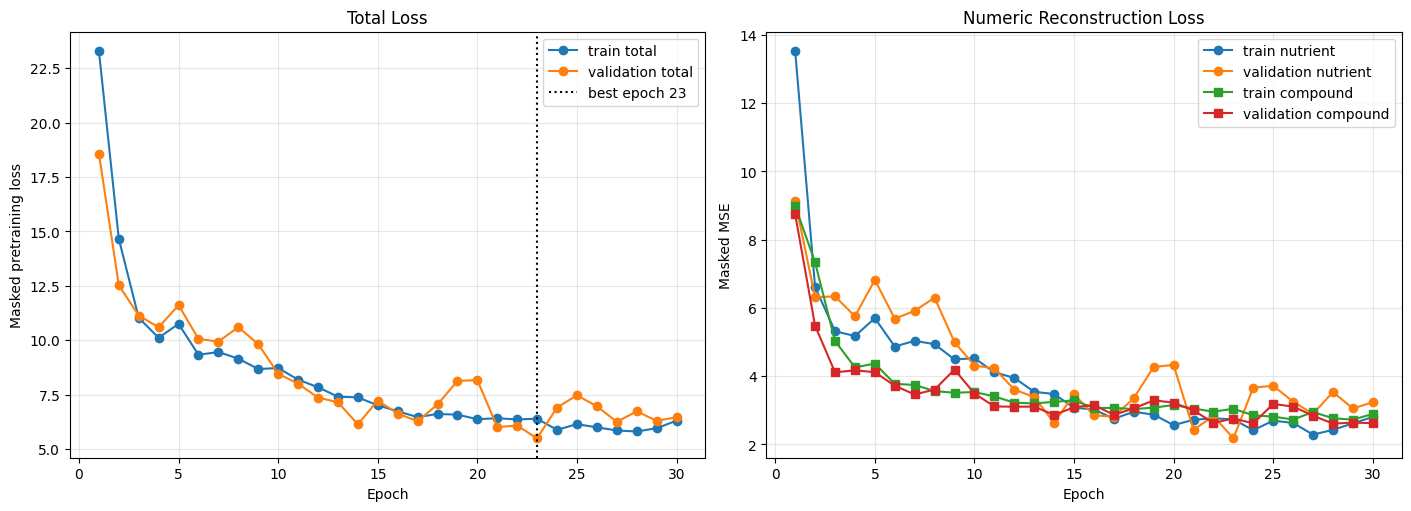

In [14]:
import matplotlib.pyplot as plt

plot_history_df = history_df.copy() if 'history_df' in globals() else pd.read_csv(metrics_path)
required_columns = [
    'epoch',
    'train_total',
    'val_total',
    'train_nutrient',
    'val_nutrient',
    'train_compound',
    'val_compound',
]
missing_columns = [column for column in required_columns if column not in plot_history_df.columns]
if missing_columns:
    raise ValueError(f'Training history is missing columns needed for plotting: {missing_columns}')

plot_best_epoch = best_epoch if 'best_epoch' in globals() and best_epoch else int(
    plot_history_df.loc[plot_history_df['val_total'].idxmin(), 'epoch']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(plot_history_df['epoch'], plot_history_df['train_total'], marker='o', label='train total')
axes[0].plot(plot_history_df['epoch'], plot_history_df['val_total'], marker='o', label='validation total')
axes[0].axvline(plot_best_epoch, color='black', linestyle=':', linewidth=1.5, label=f'best epoch {plot_best_epoch}')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Masked pretraining loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(plot_history_df['epoch'], plot_history_df['train_nutrient'], marker='o', label='train nutrient')
axes[1].plot(plot_history_df['epoch'], plot_history_df['val_nutrient'], marker='o', label='validation nutrient')
axes[1].plot(plot_history_df['epoch'], plot_history_df['train_compound'], marker='s', label='train compound')
axes[1].plot(plot_history_df['epoch'], plot_history_df['val_compound'], marker='s', label='validation compound')
axes[1].set_title('Numeric Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Masked MSE')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()

## Evaluate Against Baselines

This section loads the best checkpoint and evaluates held-out profile reconstruction with all observed test nutrient and compound values hidden from the input. It compares the model to global train means, food-group train means, and text-embedding kNN. Metrics are computed only where targets are observed.

In [11]:
def collect_predictions(model, loader, device):
    model.eval()
    collected = {
        'nutrient_pred': [],
        'compound_pred': [],
        'nutrient_target': [],
        'compound_target': [],
        'nutrient_observed_mask': [],
        'compound_observed_mask': [],
        'group_logits': [],
        'subgroup_logits': [],
        'group_label': [],
        'subgroup_label': [],
        'food_embedding': [],
    }
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            batch = move_batch_to_device(batch, device)
            outputs = model(batch)
            for key in ['nutrient_pred', 'compound_pred', 'group_logits', 'subgroup_logits', 'food_embedding']:
                collected[key].append(outputs[key].detach().cpu().numpy())
            for key in [
                'nutrient_target',
                'compound_target',
                'nutrient_observed_mask',
                'compound_observed_mask',
                'group_label',
                'subgroup_label',
            ]:
                collected[key].append(batch[key].detach().cpu().numpy())
    return {key: np.concatenate(value, axis=0) for key, value in collected.items()}


def observed_metrics(pred, target, mask):
    active = mask.astype(bool)
    if not active.any():
        return {'r2': np.nan, 'mae': np.nan, 'observed_count': 0}
    y_true = target[active].astype(np.float64)
    y_pred = pred[active].astype(np.float64)
    mae = float(np.mean(np.abs(y_pred - y_true)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    return {'r2': r2, 'mae': mae, 'observed_count': int(active.sum())}


def per_feature_metrics(pred, target, mask, columns):
    rows = []
    for feature_index, column in enumerate(columns):
        feature_mask = mask[:, feature_index].astype(bool)
        if feature_mask.sum() < 2:
            continue
        metrics = observed_metrics(
            pred[:, feature_index],
            target[:, feature_index],
            feature_mask,
        )
        rows.append(
            {
                'feature': column,
                'r2': metrics['r2'],
                'mae': metrics['mae'],
                'observed_count': metrics['observed_count'],
            }
        )
    return pd.DataFrame(rows).sort_values('r2', ascending=False)


def inverse_log_transform(values, columns, percentage_columns):
    raw = np.expm1(np.asarray(values, dtype=np.float64))
    raw = np.clip(raw, 0.0, None)
    percentage_set = set(percentage_columns)
    for index, column in enumerate(columns):
        if column in percentage_set:
            raw[:, index] = raw[:, index] * 100.0
    return raw


def feature_means(values, mask, family_name):
    means = np.full(values.shape[1], np.nan, dtype=np.float64)
    for feature_index in range(values.shape[1]):
        active = mask[:, feature_index].astype(bool)
        if active.any():
            means[feature_index] = float(values[active, feature_index].mean())
    missing = np.flatnonzero(np.isnan(means))
    if len(missing) > 0:
        fallback_values = values[mask.astype(bool)]
        if fallback_values.size == 0:
            raise ValueError(f'No observed train values are available for {family_name}.')
        fallback = float(fallback_values.mean())
        print(f'{family_name}: {len(missing)} features had no train observations; using overall train mean fallback.')
        means[missing] = fallback
    return means


def global_mean_predictions(train_values, train_mask, num_rows, family_name):
    means = feature_means(train_values, train_mask, family_name)
    return np.repeat(means.reshape(1, -1), num_rows, axis=0)


def group_mean_predictions(train_values, train_mask, train_groups, test_groups, global_means):
    predictions = np.repeat(global_means.reshape(1, -1), len(test_groups), axis=0)
    for group_id in np.unique(test_groups):
        train_group_mask = train_groups == group_id
        if not train_group_mask.any():
            continue
        group_values = train_values[train_group_mask]
        group_mask = train_mask[train_group_mask]
        group_means = global_means.copy()
        for feature_index in range(train_values.shape[1]):
            active = group_mask[:, feature_index].astype(bool)
            if active.any():
                group_means[feature_index] = float(group_values[active, feature_index].mean())
        predictions[test_groups == group_id] = group_means
    return predictions


def pooled_text_vectors(field_embeddings):
    vectors = field_embeddings.mean(axis=1).astype(np.float64)
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    return vectors / np.maximum(norms, 1e-12)


def knn_mean_predictions(train_text, train_values, train_mask, test_text, global_means, k=10):
    train_vectors = pooled_text_vectors(train_text)
    test_vectors = pooled_text_vectors(test_text)
    similarities = test_vectors @ train_vectors.T
    neighbor_count = min(k, train_vectors.shape[0])
    nearest = np.argpartition(-similarities, kth=neighbor_count - 1, axis=1)[:, :neighbor_count]
    predictions = np.repeat(global_means.reshape(1, -1), test_vectors.shape[0], axis=0)
    for row_index, neighbor_indices in enumerate(nearest):
        values = train_values[neighbor_indices]
        masks = train_mask[neighbor_indices].astype(bool)
        counts = masks.sum(axis=0)
        sums = (values * masks).sum(axis=0)
        active = counts > 0
        predictions[row_index, active] = sums[active] / counts[active]
    return predictions


def evaluation_rows(family_name, predictions, target, mask, columns, percentage_columns):
    raw_target = inverse_log_transform(target, columns, percentage_columns)
    rows = []
    for model_name, pred in predictions.items():
        transformed = observed_metrics(pred, target, mask)
        raw_pred = inverse_log_transform(pred, columns, percentage_columns)
        raw = observed_metrics(raw_pred, raw_target, mask)
        rows.append(
            {
                'family': family_name,
                'method': model_name,
                'transformed_r2': transformed['r2'],
                'transformed_mae': transformed['mae'],
                'raw_r2': raw['r2'],
                'raw_mae': raw['mae'],
                'observed_count': transformed['observed_count'],
            }
        )
    return rows


checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print('Loaded best checkpoint from:', checkpoint_path)
print('Best epoch:', checkpoint.get('best_epoch'), 'best val loss:', checkpoint.get('best_val_loss'))

profile_test_dataset = make_schema_dataset(
    'test',
    enable_random_corruption=False,
    force_profile_mask=True,
    force_metadata_mask=False,
)
profile_test_loader = DataLoader(
    profile_test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)
profile_outputs = collect_predictions(model, profile_test_loader, device)

train_indices = split_indices['train']
test_indices = split_indices['test']
train_group_labels = group_labels[train_indices]
test_group_labels = group_labels[test_indices]

nutrient_train_values = nutrient_bundle['transformed'][train_indices]
nutrient_train_mask = nutrient_bundle['mask'][train_indices]
compound_train_values = compound_bundle['transformed'][train_indices]
compound_train_mask = compound_bundle['mask'][train_indices]
train_text = text_field_embeddings[train_indices]
test_text = text_field_embeddings[test_indices]

nutrient_global_means = feature_means(nutrient_train_values, nutrient_train_mask, 'nutrients')
compound_global_means = feature_means(compound_train_values, compound_train_mask, 'compounds')

nutrient_predictions = {
    'schema_transformer': profile_outputs['nutrient_pred'],
    'global_mean': np.repeat(nutrient_global_means.reshape(1, -1), len(test_indices), axis=0),
    'food_group_mean': group_mean_predictions(
        nutrient_train_values,
        nutrient_train_mask,
        train_group_labels,
        test_group_labels,
        nutrient_global_means,
    ),
    f'text_knn_{KNN_K}': knn_mean_predictions(
        train_text,
        nutrient_train_values,
        nutrient_train_mask,
        test_text,
        nutrient_global_means,
        k=KNN_K,
    ),
}
compound_predictions = {
    'schema_transformer': profile_outputs['compound_pred'],
    'global_mean': np.repeat(compound_global_means.reshape(1, -1), len(test_indices), axis=0),
    'food_group_mean': group_mean_predictions(
        compound_train_values,
        compound_train_mask,
        train_group_labels,
        test_group_labels,
        compound_global_means,
    ),
    f'text_knn_{KNN_K}': knn_mean_predictions(
        train_text,
        compound_train_values,
        compound_train_mask,
        test_text,
        compound_global_means,
        k=KNN_K,
    ),
}

metric_rows = []
metric_rows.extend(
    evaluation_rows(
        'nutrient',
        nutrient_predictions,
        profile_outputs['nutrient_target'],
        profile_outputs['nutrient_observed_mask'],
        nutrient_columns,
        nutrient_bundle['percentage_columns'],
    )
)
metric_rows.extend(
    evaluation_rows(
        'compound',
        compound_predictions,
        profile_outputs['compound_target'],
        profile_outputs['compound_observed_mask'],
        compound_columns,
        compound_bundle['percentage_columns'],
    )
)
metrics_df = pd.DataFrame(metric_rows)
display(metrics_df)
metrics_df.to_csv(output_dir / 'schema_denoising_test_metrics.csv', index=False)

nutrient_feature_metrics = per_feature_metrics(
    nutrient_predictions['schema_transformer'],
    profile_outputs['nutrient_target'],
    profile_outputs['nutrient_observed_mask'],
    nutrient_columns,
)
compound_feature_metrics = per_feature_metrics(
    compound_predictions['schema_transformer'],
    profile_outputs['compound_target'],
    profile_outputs['compound_observed_mask'],
    compound_columns,
)
nutrient_feature_metrics.to_csv(output_dir / 'schema_denoising_per_nutrient_metrics.csv', index=False)
compound_feature_metrics.to_csv(output_dir / 'schema_denoising_per_compound_metrics.csv', index=False)

print('Lowest per-nutrient R2 values:')
display(nutrient_feature_metrics.sort_values('r2').head(10))
print('Lowest per-compound R2 values:')
display(compound_feature_metrics.sort_values('r2').head(10))

metadata_test_dataset = make_schema_dataset(
    'test',
    enable_random_corruption=False,
    force_profile_mask=False,
    force_metadata_mask=True,
)
metadata_test_loader = DataLoader(
    metadata_test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)
metadata_outputs = collect_predictions(model, metadata_test_loader, device)
group_accuracy = float((metadata_outputs['group_logits'].argmax(axis=1) == metadata_outputs['group_label']).mean())
subgroup_accuracy = float((metadata_outputs['subgroup_logits'].argmax(axis=1) == metadata_outputs['subgroup_label']).mean())
print(f'Masked group accuracy: {group_accuracy:.4f}')
print(f'Masked subgroup accuracy: {subgroup_accuracy:.4f}')

print('Saved evaluation metrics under:', output_dir)

Loaded best checkpoint from: /content/drive/MyDrive/food_model/outputs/schema_denoising_transformer/schema_denoising_food_transformer.pt
Best epoch: 23 best val loss: 5.492399682934653


  0%|          | 0/13 [00:00<?, ?it/s]

,family,method,transformed_r2,transformed_mae,raw_r2,raw_mae,observed_count
0,nutrient,schema_transformer,0.744077,1.125580,0.416255,2053.484897,1904
1,nutrient,global_mean,0.601160,1.612577,0.049787,2651.809599,1904
2,nutrient,food_group_mean,0.768572,1.127848,0.515071,1778.315166,1904
3,nutrient,text_knn_10,0.738577,1.160088,0.415451,1948.562900,1904
4,compound,schema_transformer,0.682559,1.052587,0.563408,952.826396,9432
5,compound,global_mean,0.625535,1.211280,0.536314,1000.865181,9432
6,compound,food_group_mean,0.753032,0.856547,0.733804,717.161766,9432
7,compound,text_knn_10,0.729920,0.892602,0.695234,753.799350,9432


Lowest per-nutrient R2 values:


,feature,r2,mae,observed_count
13,nutrient__18_2_t_t,-2.488626,2.061374,5
11,nutrient__18_2_i,-1.589574,1.700699,3
27,nutrient__22_1_t,-1.450893,0.408099,18
16,nutrient__18_3i,-1.329908,3.395852,2
12,nutrient__18_2_t_not_further_defined,-0.622418,1.625024,19
21,nutrient__20_3_n_6,-0.445722,1.056793,18
26,nutrient__22_1_c,-0.286471,0.827831,17
10,nutrient__18_2_clas,-0.253270,1.157970,18
8,nutrient__18_1_t,-0.196685,2.110150,22
3,nutrient__16_1_c,-0.128726,1.463630,18


Lowest per-compound R2 values:


,feature,r2,mae,observed_count
133,compound__hafnium,-3.865932e+09,1.472351,3
284,compound__yttrium,-2.473409e+09,0.612375,3
9,compound__25_hydroxycholecalciferol,-9.186843e+07,0.129715,34
220,compound__platinum,-7.363682e+07,0.499390,3
30,compound__antimony,-4.090813e+07,0.177392,4
204,compound__palladium,-1.117108e+07,0.976998,4
200,compound__osmium,-6.397730e+06,1.015172,4
194,compound__niobium,-4.479869e+06,0.620432,4
262,compound__tantalum,-6.578658e+05,0.574812,4
165,compound__lanthanum,-5.482126e+05,0.557855,4


  0%|          | 0/13 [00:00<?, ?it/s]

Masked group accuracy: 0.3154
Masked subgroup accuracy: 0.1611
Saved evaluation metrics under: /content/drive/MyDrive/food_model/outputs/schema_denoising_transformer


## Embedding Retrieval Examples

These examples use the learned `[CLS]` food embedding with nutrient and compound values hidden, so retrieval is driven by text and metadata rather than copied numeric profiles.

In [12]:
train_profile_dataset = make_schema_dataset(
    'train',
    enable_random_corruption=False,
    force_profile_mask=True,
    force_metadata_mask=False,
)
train_profile_loader = DataLoader(
    train_profile_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)
train_profile_outputs = collect_predictions(model, train_profile_loader, device)

test_embeddings = profile_outputs['food_embedding']
train_embeddings = train_profile_outputs['food_embedding']
train_norm = train_embeddings / np.maximum(np.linalg.norm(train_embeddings, axis=1, keepdims=True), 1e-12)
test_norm = test_embeddings / np.maximum(np.linalg.norm(test_embeddings, axis=1, keepdims=True), 1e-12)
similarities = test_norm @ train_norm.T

example_rows = []
for local_test_index in range(min(8, len(test_indices))):
    query_index = int(test_indices[local_test_index])
    nearest_train_local = np.argsort(-similarities[local_test_index])[:5]
    row = {
        'query_food': df.loc[query_index, 'food_name'],
        'query_group': df.loc[query_index, 'food_group'],
    }
    for rank, train_local_index in enumerate(nearest_train_local, start=1):
        train_index = int(train_indices[train_local_index])
        row[f'neighbor_{rank}'] = df.loc[train_index, 'food_name']
        row[f'neighbor_{rank}_group'] = df.loc[train_index, 'food_group']
    example_rows.append(row)

retrieval_examples_df = pd.DataFrame(example_rows)
display(retrieval_examples_df)
retrieval_examples_df.to_csv(output_dir / 'schema_denoising_retrieval_examples.csv', index=False)

  0%|          | 0/58 [00:00<?, ?it/s]

,query_food,query_group,neighbor_1,neighbor_1_group,neighbor_2,neighbor_2_group,neighbor_3,neighbor_3_group,neighbor_4,neighbor_4_group,neighbor_5,neighbor_5_group
0,Garden onion,Vegetables,Thistle,Vegetables,Leek,Vegetables,Red raspberry,Fruits,Rape,Vegetables,Persimmon,Fruits
1,Garlic,Herbs and Spices,Arabica coffee,Coffee and coffee products,Coffee,Coffee and coffee products,Asparagus,Vegetables,Common pea,Pulses,Rice,Cereals and cereal products
2,Lemon verbena,Herbs and Spices,Arctic blackberry,Fruits,Rowanberry,Fruits,Summer grape,Fruits,Jostaberry,Fruits,Water spinach,Vegetables
3,Common cabbage,Vegetables,Watermelon,Gourds,"Prunus (Cherry, Plum)",Fruits,Quince,Fruits,Garden cress,Vegetables,Endive,Vegetables
4,Cauliflower,Vegetables,Allium,Vegetables,Common oregano,Herbs and Spices,Common pea,Pulses,Sauce,Baking goods,Pasta,Cereals and cereal products
5,Chestnut,Nuts,Marshmallow,Confectioneries,Ketchup,Baking goods,Cottonseed,Herbs and Spices,Common thyme,Herbs and Spices,Other bread product,Cereals and cereal products
6,"Mandarin orange (Clementine, Tangerine)",Fruits,Common grape,Fruits,Peach,Fruits,Kiwi,Fruits,Tea,Teas,Mango,Fruits
7,Muskmelon,Gourds,Asparagus,Vegetables,Pepper (Spice),Herbs and Spices,Garden rhubarb,Vegetables,Ginger,Herbs and Spices,Apricot,Fruits


## Inspect Saved Outputs

In [13]:
print('Checkpoint:', checkpoint_path, checkpoint_path.exists())
print('History:', metrics_path, metrics_path.exists())
print('Config:', config_path, config_path.exists())
print('Test metrics:', output_dir / 'schema_denoising_test_metrics.csv')

if metrics_path.exists():
    display(pd.read_csv(metrics_path).tail())

Checkpoint: /content/drive/MyDrive/food_model/outputs/schema_denoising_transformer/schema_denoising_food_transformer.pt True
History: /content/drive/MyDrive/food_model/outputs/schema_denoising_transformer/schema_denoising_food_transformer_history.csv True
Config: /content/drive/MyDrive/food_model/outputs/schema_denoising_transformer/schema_denoising_food_transformer_config.json True
Test metrics: /content/drive/MyDrive/food_model/outputs/schema_denoising_transformer/schema_denoising_test_metrics.csv


,epoch,learning_rate,train_total,train_nutrient,train_compound,train_group,train_subgroup,val_total,val_nutrient,val_compound,val_group,val_subgroup
25,26,0.000022,5.999094,2.629434,2.728611,2.426714,3.983773,6.969172,3.253235,3.108104,2.281639,3.796685
26,27,0.000019,5.855365,2.287354,2.949348,2.355843,3.830789,6.253596,2.895770,2.842557,1.935987,3.216699
27,28,0.000016,5.807503,2.427134,2.766031,2.259729,3.883649,6.731907,3.535273,2.610542,2.044177,3.816737
28,29,0.000014,5.959328,2.616368,2.727360,2.314786,3.841218,6.301397,3.053773,2.638625,1.954221,4.135764
29,30,0.000012,6.302932,2.804652,2.892367,2.268501,3.790634,6.460730,3.236062,2.624660,2.249412,3.750664
